In [242]:
from read_model_runs import read_model_runs

# Ler dados completos
question_long_df = read_model_runs('../data/processed/model-runs')

# Filtrar apenas as linhas em português
question_long_df = question_long_df[question_long_df["language"] == "portuguese"].copy()

print('shape', question_long_df.shape)

question_long_df.head()


shape (3988, 20)


,model_name,firac,language,is_correct,pdf_filename,question_id,materia,prova,questao,enunciado,prompt,A,B,C,D,resposta_completa,alternativa,rule_count,correct,response_time_seconds
0,gemini-2.0-flash-lite,FIL__,portuguese,0,oab-26.pdf,oab-26.pdf-260,ÉTICA PROFISSIONAL,XXVII,260,"A advogada Mariana, gestante, ao ingressar em ...",Resolva a questão do exame da ordem da OAB aba...,Mariana tem o direito de não ser submetida a a...,Mariana tem o direito de não ser submetida a a...,"Mariana deverá, por medida de segurança, passa...","Mariana tem o direito, independentemente do te...",resposta: B\n,B,1.0,D,0.681947
1,gemini-2.0-flash-lite,FIL__,portuguese,1,oab-327.pdf,oab-327.pdf-055,PROCESSO DO TRABALHO,V,55,Com relação à competência material da Justiça ...,Resolva a questão do exame da ordem da OAB aba...,"não compete à Justiça do Trabalho, mas à Justi...",é da competência da Justiça do Trabalho o julg...,de acordo com o entendimento do Superior Tribu...,a Justiça do Trabalho é competente para julgar...,resposta: D\n,D,5.0,D,1.288225
2,gemini-2.0-flash-lite,FIL__,portuguese,0,oab-336.pdf,oab-336.pdf-151,PROCESSO DO TRABALHO,XXXI,151,Você foi contratado(a) para atuar nas seguinte...,Resolva a questão do exame da ordem da OAB aba...,Tanto na ação de cumprimento como na ação plúr...,O sindicato de classe da categoria poderá repr...,"Nas ações plúrima e de cumprimento, a parte au...",O sindicato da categoria poderá representar os...,resposta: D\n,D,6.0,C,1.319898
3,gemini-2.0-flash-lite,FIL__,portuguese,1,oab-95.pdf,oab-95.pdf-076,DIREITO INTERNACIONAL,XL,76,"Uma sociedade empresária colombiana celebrou, ...",Resolva a questão do exame da ordem da OAB aba...,"A autoridade judiciária inglesa, única e exclu...","A autoridade judiciária colombiana, concorrent...","A autoridade judiciária alemã, única e exclusi...","A autoridade judiciária brasileira, concorrent...",resposta: D\n,D,2.0,D,0.585031
4,gemini-2.0-flash-lite,FIL__,portuguese,1,oab-28.pdf,oab-28.pdf-275,ÉTICA PROFISSIONAL,XXIX,275,A Sociedade de Advogados X pretende associar-s...,Resolva a questão do exame da ordem da OAB aba...,"É autorizada, contudo deve haver formalização ...","É autorizada, contudo deve haver formalização ...","É autorizada, independentemente de averbação n...","Não é autorizada, pois os advogados João e Mar...",resposta: B\n,B,2.0,B,0.601043


Existe missing data?

In [243]:
question_long_df.isna().sum()


model_name               0
firac                    0
language                 0
is_correct               0
pdf_filename             0
question_id              0
materia                  0
prova                    0
questao                  0
enunciado                0
prompt                   0
A                        0
B                        0
C                        0
D                        0
resposta_completa        0
alternativa              6
rule_count               0
correct                  0
response_time_seconds    0
dtype: int64

In [244]:
question_long_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3988 entries, 0 to 3987
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   model_name             3988 non-null   object 
 1   firac                  3988 non-null   object 
 2   language               3988 non-null   object 
 3   is_correct             3988 non-null   int32  
 4   pdf_filename           3988 non-null   object 
 5   question_id            3988 non-null   object 
 6   materia                3988 non-null   object 
 7   prova                  3988 non-null   object 
 8   questao                3988 non-null   object 
 9   enunciado              3988 non-null   object 
 10  prompt                 3988 non-null   object 
 11  A                      3988 non-null   object 
 12  B                      3988 non-null   object 
 13  C                      3988 non-null   object 
 14  D                      3988 non-null   object 
 15  resposta_

In [245]:
import pandas as pd

# 1. Calcular acurácia média global por firac (para ordenar as colunas)
firac_order = (
    question_long_df
    .groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# 2. Criar pivot table: cada linha = question_id, cada coluna = firac, valor = média de is_correct
question_wide_df = question_long_df.pivot_table(
    index="question_id",
    columns="firac",
    values="is_correct",
    aggfunc="mean"
).reindex(columns=firac_order)  # reordenar colunas pela acurácia média global

# 3. Resetar índice se quiser question_id como coluna normal
question_wide_df = question_wide_df.reset_index()

# 4. Mostrar o resultado
question_wide_df.head()


firac,question_id,FIRAC,FIRA_,FIR__,__R__,FI___,FIL__,__L__,____,F____
0,oab-10.pdf-094,1.0,0.888889,1.000000,1.0,0.666667,0.5,0.700000,0.700000,0.700000
1,oab-110.pdf-118,1.0,0.777778,0.888889,0.8,0.700000,0.7,0.400000,0.400000,0.400000
2,oab-112.pdf-140,1.0,1.000000,1.000000,0.9,0.600000,0.8,0.700000,0.444444,0.555556
3,oab-115.pdf-168,1.0,1.000000,0.666667,0.9,0.600000,0.6,0.777778,0.700000,0.666667
4,oab-13.pdf-123,1.0,1.000000,1.000000,1.0,0.800000,0.8,0.700000,0.800000,0.800000


In [246]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Separar índice e variáveis
question_ids = question_wide_df['question_id']
X = question_wide_df.drop(columns='question_id')

# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA
pca = PCA(n_components=len(X.columns))  # todos os componentes
X_pca = pca.fit_transform(X_scaled)

# Criar DataFrame com PCs
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X.shape[1])])
pca_df['question_id'] = question_ids

# Mostrar loadings (como cada PC combina com as variáveis originais)
loadings = pd.DataFrame(pca.components_.T, 
                        columns=[f'PC{i+1}' for i in range(X.shape[1])],
                        index=X.columns)

print("Loadings (peso das variáveis em cada PC):")
print(loadings)

# Proporção de variância explicada
print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)


Loadings (peso das variáveis em cada PC):
            PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
firac                                                                         
FIRAC  0.135005  0.695481  0.324192  0.618961  0.005111 -0.066688 -0.009249   
FIRA_  0.229428  0.211552  0.678949 -0.606210 -0.084385  0.238324 -0.027801   
FIR__  0.292697  0.431190 -0.372872 -0.425144  0.212108 -0.587729 -0.070525   
__R__  0.305079  0.313269 -0.529776 -0.059471 -0.377398  0.591176 -0.001316   
FI___  0.384258 -0.165388  0.011344  0.175435  0.499699  0.055646 -0.216317   
FIL__  0.385851 -0.109839 -0.022091  0.022531  0.536336  0.296772  0.427540   
__L__  0.385574 -0.193089  0.070355  0.113657 -0.392823 -0.263439  0.628404   
____   0.388753 -0.239844  0.084310  0.078413 -0.303440 -0.283186 -0.170910   
F____  0.392505 -0.230789  0.039456  0.121497 -0.147286  0.055459 -0.583507   

            PC8       PC9  
firac                      
FIRAC  0.026108 -0.068017  
FIRA

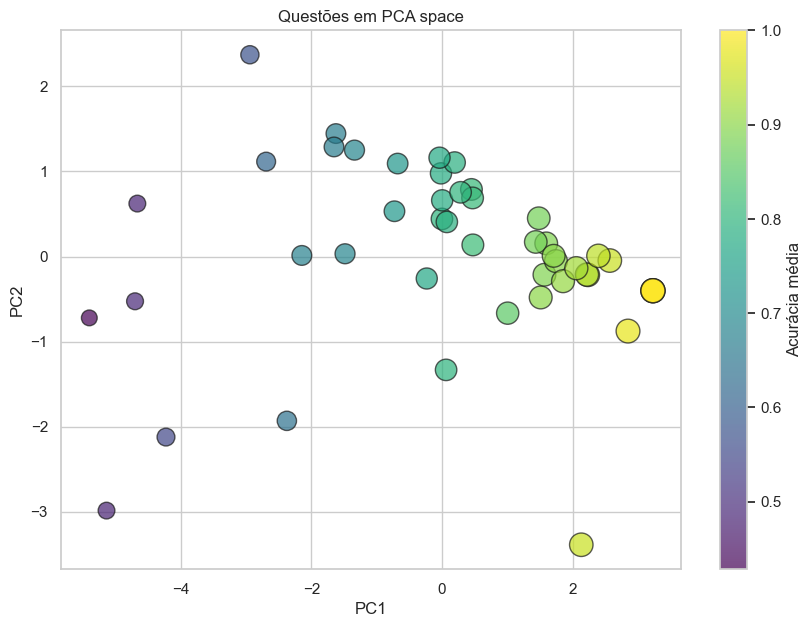

In [247]:
import matplotlib.pyplot as plt

# Calcular acurácia média por questão
question_wide_df['accuracy_mean'] = question_wide_df.drop(columns='question_id').mean(axis=1)

# Criar scatter plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    pca_df['PC1'], 
    pca_df['PC2'], 
    s=question_wide_df['accuracy_mean'] * 300,  # tamanho proporcional à acurácia
    c=question_wide_df['accuracy_mean'],       # cor proporcional à acurácia
    cmap='viridis',
    alpha=0.7,
    edgecolor='k'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Questões em PCA space')
plt.colorbar(scatter, label='Acurácia média')
plt.grid(True)
plt.show()


In [248]:
# -----------------------
# Calcular acurácia, tamanho médio do enunciado, média de rule_count e tempo médio de resposta por questão
# -----------------------
question_agg_df = (
    question_long_df
    .groupby("question_id")
    .agg(
        accuracy=("is_correct", "mean"),
        question_body_length=("enunciado", lambda x: x.str.len().mean()),
        rule_count=("rule_count", "mean"),
        response_time_seconds=("response_time_seconds", "mean")
    )
    .reset_index()
)

# Ordenar por accuracy
question_agg_df = question_agg_df.sort_values(by="accuracy", ascending=True).reset_index(drop=True)

# Visualizar as primeiras linhas
question_agg_df.head()


,question_id,accuracy,question_body_length,rule_count,response_time_seconds
0,oab-26.pdf-260,0.418605,254.0,1.0,3.988195
1,oab-292.pdf-210,0.471264,632.0,2.0,5.380981
2,oab-29.pdf-288,0.471264,355.0,2.0,7.798318
3,oab-283.pdf-115,0.482759,958.0,3.0,4.267372
4,oab-308.pdf-118,0.550562,329.0,2.0,5.069596


In [277]:
import pandas as pd
import numpy as np

# 1. Calcular a acurácia média global por firac (para ordenar dificuldade)
firac_difficulty = (
    question_long_df
    .groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)  # mais fácil primeiro
    .reset_index()
)

# 2. Criar um mapeamento da dificuldade ordinal (0 = mais fácil, N = mais difícil)
firac_order = {firac: i for i, firac in enumerate(firac_difficulty["firac"])}

# 3. Adicionar a ordem de dificuldade no dataframe original
df = question_long_df.copy()
df["firac_order"] = df["firac"].map(firac_order)

# 4. Função que retorna número de inconsistências e vetor de respostas
def guttman_info(df_model):
    """
    Retorna o número de inconsistências e o vetor de respostas (0/1)
    ordenado pela dificuldade (firac_order).
    Uma inconsistência ocorre quando uma questão mais fácil é errada (0)
    e uma mais difícil é acertada (1).
    """
    # Ordenar por dificuldade
    df_sorted = df_model.sort_values("firac_order")

    # Vetor de acertos (0 = erro, 1 = acerto)
    y = df_sorted["is_correct"].values

    # Calcular inconsistências
    n_inconsistencias = 0
    for i in range(len(y)):
        for j in range(i + 1, len(y)):
            if y[i] < y[j]:  # violação da ordem esperada
                n_inconsistencias += 1

    # Criar representação do vetor (ex: "10110")
    response_vector = "".join(map(str, y))

    return pd.Series({
        "n_inconsistencias": n_inconsistencias,
        "response_vector": response_vector
    })

# 5. Calcular número de inconsistências e vetor por modelo e questão
model_guttmann_df = (
    df
    .groupby(["model_name", "question_id"])
    .apply(guttman_info)
    .reset_index()
)

# 6. Ordenar pelo número de inconsistências (menor → mais consistente)
gutmann_long_df = model_guttmann_df.sort_values("n_inconsistencias", ascending=False).reset_index(drop=True)

# 7. Visualizar resultado
gutmann_long_df.head(100)

gutmann_long_df = gutmann_long_df[gutmann_long_df["model_name"] == "gemma-3-1b-it"].copy()

# Exibir as 100 primeiras linhas
gutmann_long_df.head(200)

C:\Users\pedro\AppData\Local\Temp\ipykernel_13964\1460317126.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(guttman_info)


,model_name,question_id,n_inconsistencias,response_vector
4,gemma-3-1b-it,oab-283.pdf-114,10,0011111
6,gemma-3-1b-it,oab-279.pdf-072,9,000111
9,gemma-3-1b-it,oab-167.pdf-149,7,101111111
11,gemma-3-1b-it,oab-170.pdf-180,7,01111111
13,gemma-3-1b-it,oab-99.pdf-009,6,001110
17,gemma-3-1b-it,oab-115.pdf-168,6,100111
38,gemma-3-1b-it,oab-189.pdf-079,4,000010
72,gemma-3-1b-it,oab-110.pdf-118,2,001000
78,gemma-3-1b-it,oab-316.pdf-196,2,001000
79,gemma-3-1b-it,oab-327.pdf-055,2,001000


In [250]:
import pandas as pd
import numpy as np

# 1. Calcular a acurácia média global por firac (para ordenar dificuldade)
firac_difficulty = (
    question_long_df
    .groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)  # mais fácil primeiro
    .reset_index()
)

# 2. Criar um mapeamento da dificuldade ordinal (0 = mais fácil, N = mais difícil)
firac_order = {firac: i for i, firac in enumerate(firac_difficulty["firac"])}

# 3. Adicionar a ordem de dificuldade no dataframe original
df = question_long_df.copy()
df["firac_order"] = df["firac"].map(firac_order)

# 4. Função que calcula inconsistências por transição de firac
def guttman_per_firac(df_model):
    df_sorted = df_model.sort_values("firac_order")
    y = df_sorted["is_correct"].values
    firacs = df_sorted["firac"].values
    
    inconsistencias_por_firac = {}
    for i in range(1, len(y)):
        if y[i-1] < y[i]:
            inconsistencias_por_firac[firacs[i]] = inconsistencias_por_firac.get(firacs[i], 0) + 1
        else:
            inconsistencias_por_firac[firacs[i]] = inconsistencias_por_firac.get(firacs[i], 0)
    
    # Transformar em DataFrame long
    df_long = pd.DataFrame({
        "firac": list(inconsistencias_por_firac.keys()),
        "n_inconsistencias": list(inconsistencias_por_firac.values())
    })
    
    df_long["response_vector"] = "".join(map(str, y))
    
    return df_long

# 5. Aplicar por modelo e questão e concatenar resultados
result_list = []

for (model, question), group in df.groupby(["model_name", "question_id"]):
    df_long = guttman_per_firac(group)
    df_long["model_name"] = model
    df_long["question_id"] = question
    result_list.append(df_long)

guttmann_per_firac_df = pd.concat(result_list, ignore_index=True)

# 6. Visualizar resultado
guttmann_per_firac_df.head(20)


,firac,n_inconsistencias,response_vector,model_name,question_id
0,FIRA_,0,111111111,gemini-2.0-flash,oab-10.pdf-094
1,FIR__,0,111111111,gemini-2.0-flash,oab-10.pdf-094
2,__R__,0,111111111,gemini-2.0-flash,oab-10.pdf-094
3,FI___,0,111111111,gemini-2.0-flash,oab-10.pdf-094
4,FIL__,0,111111111,gemini-2.0-flash,oab-10.pdf-094
5,__L__,0,111111111,gemini-2.0-flash,oab-10.pdf-094
6,____,0,111111111,gemini-2.0-flash,oab-10.pdf-094
7,F____,0,111111111,gemini-2.0-flash,oab-10.pdf-094
8,FIRA_,0,111111000,gemini-2.0-flash,oab-110.pdf-118
9,FIR__,0,111111000,gemini-2.0-flash,oab-110.pdf-118


In [251]:
import pandas as pd

# Agrupar por firac e calcular estatísticas
firac_stats_df = (
    guttmann_per_firac_df
    .groupby("firac")["n_inconsistencias"]
    .agg(
        mean_inconsistencias="mean",
        median_inconsistencias="median",
        std_inconsistencias="std"
    )
    .reset_index()
)

# Ordenar por dificuldade se desejar (opcional)
firac_stats_df = firac_stats_df.sort_values("mean_inconsistencias", ascending=False)

# Visualizar resultado
firac_stats_df


,firac,mean_inconsistencias,median_inconsistencias,std_inconsistencias
5,__L__,0.067686,0.0,0.251480
4,F____,0.059735,0.0,0.237257
0,FIL__,0.052747,0.0,0.223775
7,____,0.049107,0.0,0.216333
3,FI___,0.030501,0.0,0.172149
6,__R__,0.021378,0.0,0.144812
2,FIR__,0.009569,0.0,0.097471
1,FIRA_,0.002398,0.0,0.048970


C:\Users\pedro\AppData\Local\Temp\ipykernel_13964\1399155143.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


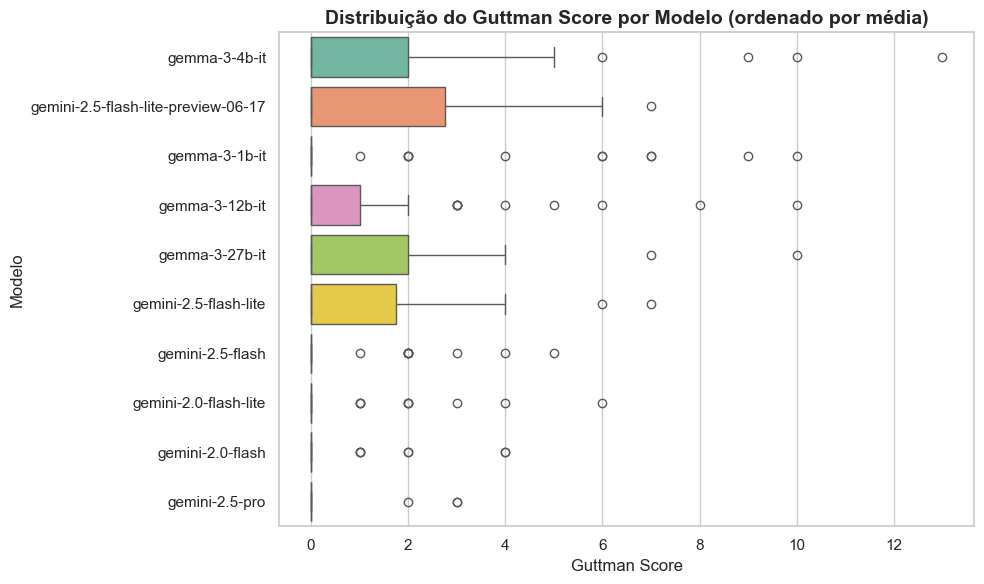

In [274]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular a mediana do Guttman score por modelo
mean_order = (
    model_guttmann_df.groupby("model_name")["n_inconsistencias"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# 2. Plotar boxplot ordenado
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

sns.boxplot(
    data=model_guttmann_df,
    y="model_name",
    x="n_inconsistencias",
    order=mean_order,      # ordena do maior pro menor
    palette="Set2",
    orient="h"               # horizontal pra melhor leitura
)

# 3. Ajustes visuais
plt.title("Distribuição do Guttman Score por Modelo (ordenado por média)", fontsize=14, weight='bold')
plt.xlabel("Guttman Score", fontsize=12)
plt.ylabel("Modelo", fontsize=12)
#plt.xlim(0.4, 1.1)  # intervalo pedido
plt.tight_layout()

plt.show()


In [253]:
# Mostra 'resposta_completa' quando 'alternativa' está vazia ou é NaN
question_long_df.loc[question_long_df['alternativa'].isna(), 'resposta_completa']


1875    A questão aborda os princípios da solidariedad...
1957    A questão aborda os institutos da solidariedad...
2002    A questão aborda a responsabilidade tributária...
2918    A resposta correta é B.\n\n**Justificativa:**\...
2921                                                  D\n
2929                                                 A: 3
Name: resposta_completa, dtype: object

In [254]:
import pandas as pd

# Supondo que question_long_df já está carregado

# Cálculo da acurácia média por modelo e por firac
model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)
model_accuracy["model_order"] = range(1, len(model_accuracy) + 1)

firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)
firac_accuracy["firac_order"] = range(1, len(firac_accuracy) + 1)

# Exibindo os resultados
print("Model order:")
print(model_accuracy)

print("\nFirac order:")
print(firac_accuracy)

model_order_accuracy = model_accuracy[["model_name"]].values
firac_order_accuracy = firac_accuracy[["firac"]].values




Model order:
                            model_name  is_correct  model_order
0                        gemma-3-1b-it    0.353952            1
1                        gemma-3-4b-it    0.586957            2
2                       gemma-3-27b-it    0.756039            3
3                       gemma-3-12b-it    0.768116            4
4                gemini-2.5-flash-lite    0.811138            5
5  gemini-2.5-flash-lite-preview-06-17    0.833333            6
6                gemini-2.0-flash-lite    0.836585            7
7                     gemini-2.0-flash    0.838164            8
8                     gemini-2.5-flash    0.933333            9
9                       gemini-2.5-pro    0.990338           10

Firac order:
   firac  is_correct  firac_order
0  F____    0.654867            1
1   ____    0.658482            2
2  __L__    0.663755            3
3  FIL__    0.696703            4
4  FI___    0.697168            5
5  __R__    0.836601            6
6  FIR__    0.909953           

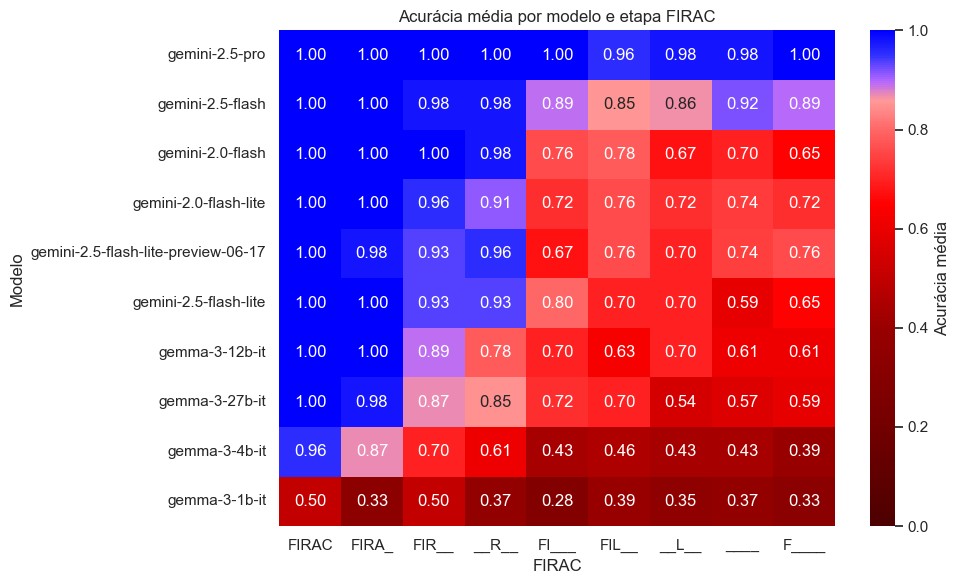

In [255]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1. Calcular acurácia média por modelo e firac
heatmap_data = (
    question_long_df
    .groupby(["model_name", "firac"])["is_correct"]
    .mean()
    .unstack()
)

# 2. Calcular ordem dos modelos e FIRAC
model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)
firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)

model_order_accuracy = model_accuracy.index.tolist()
firac_order_accuracy = firac_accuracy.index.tolist()

# 3. Reordenar DataFrame
heatmap_data = heatmap_data.loc[model_order_accuracy, firac_order_accuracy]

# 4. Colormap com nuances vermelhas e transição suave após 0.9
custom_cmap = LinearSegmentedColormap.from_list(
    "detailed_red_blue",
    [
        (0.0, "#4d0000"),   # 0.00 = vermelho muito escuro
        (0.4, "#990000"),   # 0.40 = vermelho forte
        (0.65, "#ff0000"),  # 0.65 = vermelho puro
        (0.80, "#ff6666"),  # 0.80 = vermelho claro
        (0.86, "#ff9999"),  # 0.86 = rosado
        (0.90, "#b366ff"),  # 0.90 = começa roxo
        (0.95, "#3333ff"),  # 0.95 = azul forte
        (1.0, "blue")       # 1.00 = azul puro
    ]
)

# 5. Plotar o heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Acurácia média'}
)
plt.title("Acurácia média por modelo e etapa FIRAC")
plt.xlabel("FIRAC")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()


In [256]:
!pip install adjustText


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: C:\Users\pedro\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


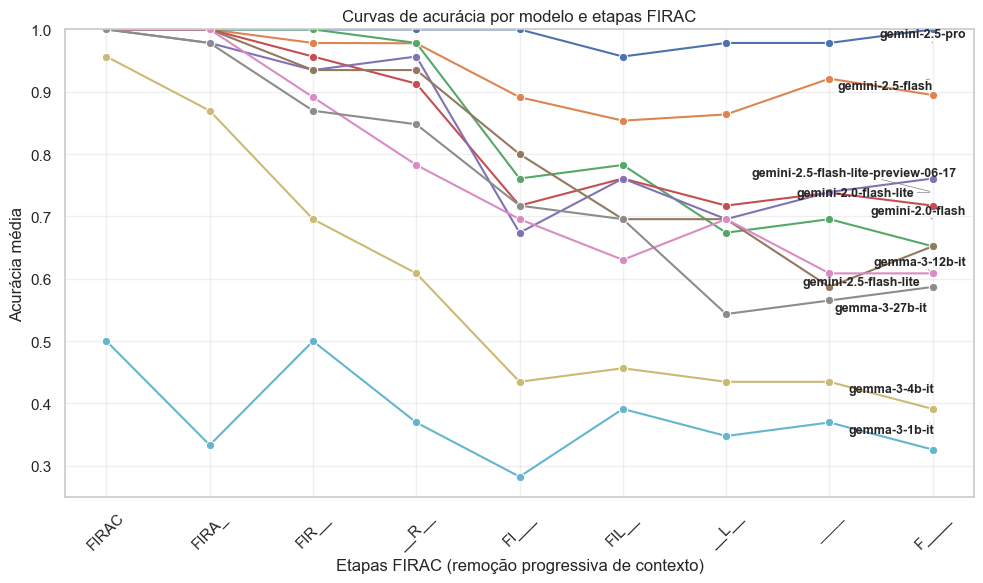

In [257]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

# 1. Calcular acurácia média por modelo e firac
curve_data = (
    question_long_df
    .groupby(["model_name", "firac"])["is_correct"]
    .mean()
    .reset_index()
)

# 2. Calcular ordem dos modelos e FIRAC
model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)
firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)

model_order_accuracy = model_accuracy.index.tolist()
firac_order_accuracy = firac_accuracy.index.tolist()

# 3. Garantir que as colunas sejam categóricas e ordenadas
curve_data["firac"] = pd.Categorical(
    curve_data["firac"], 
    categories=firac_order_accuracy, 
    ordered=True
)
curve_data["model_name"] = pd.Categorical(
    curve_data["model_name"], 
    categories=model_order_accuracy, 
    ordered=True
)

# 4. Plotar as curvas sem legenda
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=curve_data,
    x="firac",
    y="is_correct",
    hue="model_name",
    hue_order=model_order_accuracy,
    marker="o",
    legend=False
)

# 5. Adicionar labels perto das curvas
texts = []
for model in curve_data["model_name"].unique():
    subset = curve_data[curve_data["model_name"] == model]
    last_x = subset["firac"].iloc[-1]
    last_y = subset["is_correct"].iloc[-1]
    texts.append(
        plt.text(
            x=len(firac_order_accuracy) - 1,  # posição no eixo x
            y=last_y,
            s=model,
            fontsize=9,
            fontweight="bold"
        )
    )

# Ajustar automaticamente para evitar sobreposição
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

# 6. Estilização
plt.title("Curvas de acurácia por modelo e etapas FIRAC")
plt.xlabel("Etapas FIRAC (remoção progressiva de contexto)")
plt.ylabel("Acurácia média")
plt.ylim(0.25, 1)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [258]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

# -----------------------
# 1. Calcular acurácia média por modelo e firac
# -----------------------
curve_data = (
    question_long_df
    .groupby(["model_name", "firac"])["is_correct"]
    .mean()
    .reset_index()
)

# -----------------------
# 2. Calcular ordem dos modelos e FIRAC
# -----------------------
model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)
firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)

model_order_accuracy = model_accuracy.index.tolist()
firac_order_accuracy = firac_accuracy.index.tolist()

# -----------------------
# 3. Garantir que as colunas sejam categóricas e ordenadas
# -----------------------
curve_data["firac"] = pd.Categorical(
    curve_data["firac"], 
    categories=firac_order_accuracy, 
    ordered=True
)
curve_data["model_name"] = pd.Categorical(
    curve_data["model_name"], 
    categories=model_order_accuracy, 
    ordered=True
)

# -----------------------
# 4. Calcular AUC (área sob a curva FIRAC) para cada modelo
# -----------------------
auc_df = []

for model in curve_data["model_name"].unique():
    subset = curve_data[curve_data["model_name"] == model].sort_values("firac")
    # Como 'firac' é categórico, usamos índices numéricos igualmente espaçados
    x = np.arange(len(subset))
    y = subset["is_correct"].values
    auc_value = np.trapz(y, x) / (len(x) - 1)  # normalizar entre 0–1 se desejar
    
    # Calcular a acurácia original (firac == "_____")
    acc_original = (
        subset.loc[subset["firac"] == "____", "is_correct"]
        .values[0]
        if "____" in subset["firac"].values else np.nan
    )
    
    auc_df.append({
        "model_name": model,
        "acc_original": acc_original,
        "auc_firac": auc_value,
    })

auc_df = pd.DataFrame(auc_df)

# -----------------------
# 5. Calcular média e desvio-padrão de inconsistências (Guttman) por modelo
# -----------------------
gutmann_stats_df = (
    gutmann_long_df
    .groupby("model_name")["n_inconsistencias"]
    .agg(gutmann_avg_score="mean", gutmann_std_score="std")
    .reset_index()
)

# -----------------------
# 6. Fazer o join com auc_df
# -----------------------
auc_df = auc_df.merge(gutmann_stats_df, on="model_name", how="left")

# -----------------------
# 7. Ordenar pelo AUC (ou pelo Guttman médio, se preferir)
# -----------------------
auc_df = auc_df.sort_values("auc_firac", ascending=False).reset_index(drop=True)

auc_df.head(100)


,model_name,acc_original,auc_firac,gutmann_avg_score,gutmann_std_score
0,gemini-2.5-pro,0.978261,0.989130,0.173913,0.676736
1,gemini-2.5-flash,0.921053,0.929132,0.500000,1.149879
2,gemini-2.0-flash,0.695652,0.839674,0.326087,0.920250
3,gemini-2.0-flash-lite,0.738095,0.832751,0.478261,1.206264
4,gemini-2.5-flash-lite-preview-06-17,0.739130,0.827446,1.260870,1.925672
5,gemini-2.5-flash-lite,0.586957,0.809239,0.934783,1.583276
6,gemma-3-12b-it,0.608696,0.763587,1.108696,2.263019
7,gemma-3-27b-it,0.565217,0.751359,1.065217,1.936803
8,gemma-3-4b-it,0.434783,0.576087,1.543478,2.964280
9,gemma-3-1b-it,0.369565,0.375906,1.217391,2.632388


In [278]:
auc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   model_name         10 non-null     object 
 1   acc_original       10 non-null     float64
 2   auc_firac          10 non-null     float64
 3   gutmann_avg_score  10 non-null     float64
 4   gutmann_std_score  10 non-null     float64
dtypes: float64(4), object(1)
memory usage: 532.0+ bytes


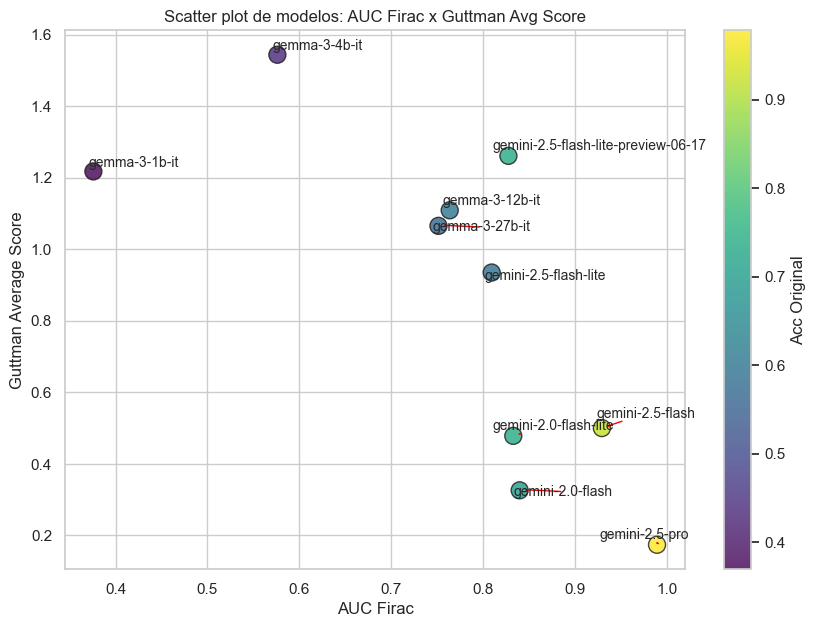

In [280]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

plt.figure(figsize=(10, 7))

# Scatter plot
scatter = plt.scatter(
    auc_df['auc_firac'], 
    auc_df['gutmann_avg_score'], 
    c=auc_df['acc_original'], 
    s=150,
    cmap='viridis',
    alpha=0.8,
    edgecolor='k'
)

# Adicionar labels dos modelos com offset
texts = []
offset_x = 0.002  # ajuste horizontal (direita)
offset_y = 0.002  # ajuste vertical (para cima)

for i, row in auc_df.iterrows():
    texts.append(
        plt.text(
            row['auc_firac'] + offset_x, 
            row['gutmann_avg_score'] + offset_y, 
            row['model_name'], 
            fontsize=10
        )
    )

# Ajustar texto para não sobrepor
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Eixos e título
plt.xlabel('AUC Firac')
plt.ylabel('Guttman Average Score')
plt.title('Scatter plot de modelos: AUC Firac x Guttman Avg Score')
plt.colorbar(scatter, label='Acc Original')
plt.grid(True)
plt.show()


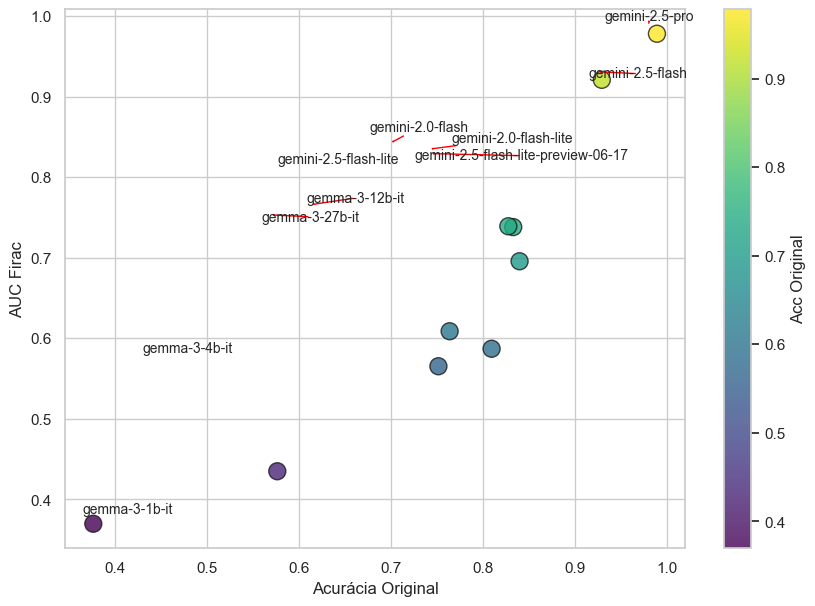

In [ ]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

plt.figure(figsize=(10, 7))

# Scatter plot
scatter = plt.scatter(
    auc_df['acc_original'], 
    auc_df['auc_firac'], 
    c=auc_df['acc_original'], 
    s=150,
    cmap='viridis',
    alpha=0.8,
    edgecolor='k'
)

# Adicionar labels dos modelos com offset
texts = []
offset_x = 0.002  # ajuste horizontal (direita)
offset_y = 0.002  # ajuste vertical (para cima)

for i, row in auc_df.iterrows():
    texts.append(
        plt.text(
            row['acc_original'] + offset_x, 
            row['auc_firac'] + offset_y, 
            row['model_name'], 
            fontsize=10
        )
    )

# Ajustar texto para não sobrepor
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Eixos e título
plt.xlabel('Acurácia Original')
plt.ylabel('AUC Firac')
plt.colorbar(scatter, label='Acc Original')
plt.grid(True)
plt.show()


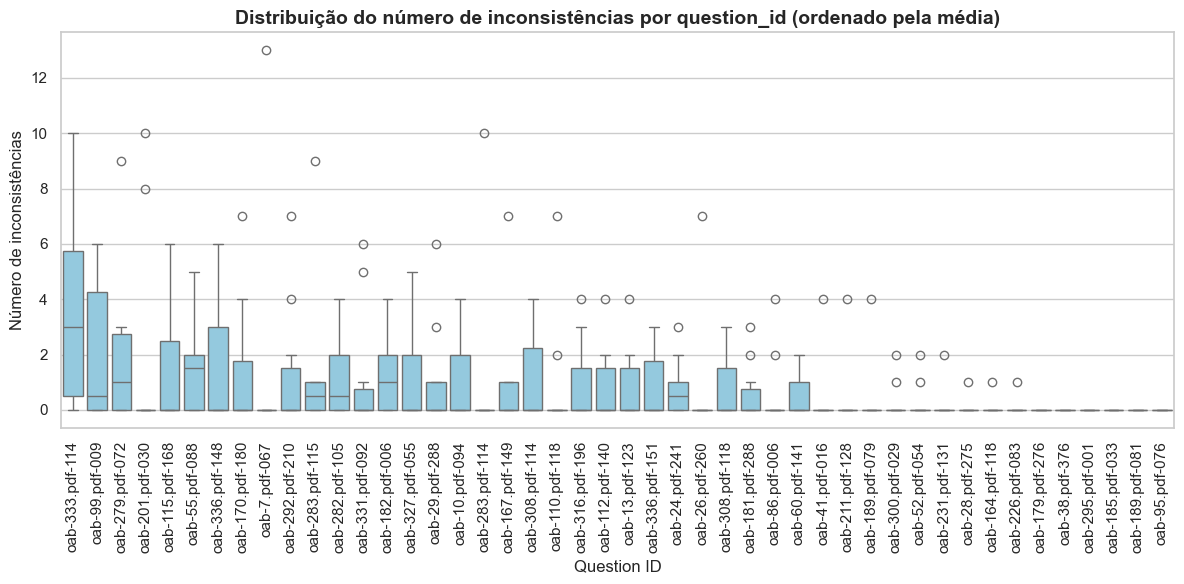

In [259]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calcular média de inconsistências por questão
question_order = (
    gutmann_long_df
    .groupby("question_id")["n_inconsistencias"]
    .mean()
    .sort_values(ascending=False)  # do maior para o menor
    .index
)

plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Boxplot de inconsistências por questão, ordenado pela média
sns.boxplot(
    data=gutmann_long_df,
    x="question_id",
    y="n_inconsistencias",
    order=question_order,
    color="skyblue"
)

plt.title("Distribuição do número de inconsistências por question_id (ordenado pela média)", fontsize=14, weight="bold")
plt.xlabel("Question ID", fontsize=12)
plt.ylabel("Número de inconsistências", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


C:\Users\pedro\AppData\Local\Temp\ipykernel_13964\313051386.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_curve = data.groupby("firac")["is_correct"].mean().reset_index()
C:\Users\pedro\AppData\Local\Temp\ipykernel_13964\313051386.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_curve = data.groupby("firac")["is_correct"].mean().reset_index()
C:\Users\pedro\AppData\Local\Temp\ipykernel_13964\313051386.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True t

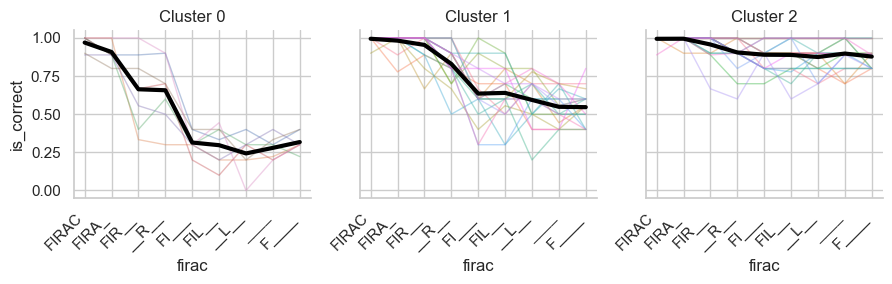

C:\Users\pedro\AppData\Local\Temp\ipykernel_13964\313051386.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  curve_data.groupby(["cluster", "firac"])["is_correct"]


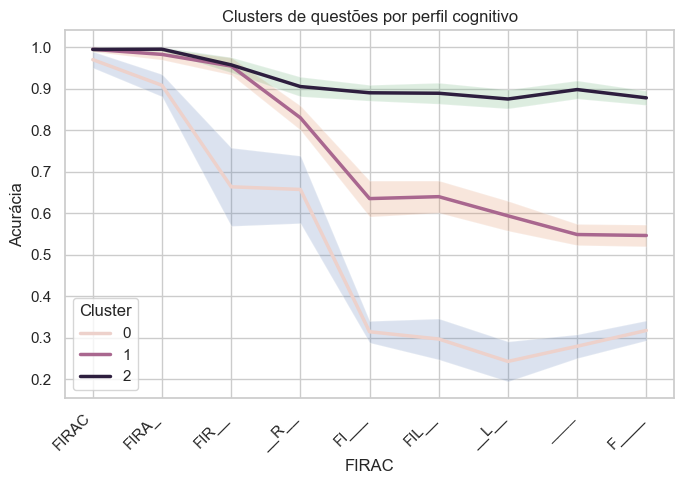

In [260]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


# -----------------------
# 1. Transformar para wide format
# -----------------------
# 1. Calcular acurácia média por modelo e firac]

curve_data = (
    question_long_df
    .groupby(["question_id", "firac"])["is_correct"]
    .mean()
    .reset_index()
)


curve_wide = curve_data.pivot(index="question_id", columns="firac", values="is_correct").fillna(0)


# -----------------------
# 2. Clusterizar as curvas semelhantes
# -----------------------
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(curve_wide)

curve_data = curve_data.merge(
    pd.DataFrame({"question_id": curve_wide.index, "cluster": clusters}),
    on="question_id"
)

model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)
firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)

model_order_accuracy = model_accuracy.index.tolist()
firac_order_accuracy = firac_accuracy.index.tolist()


# 3. Garantir que as colunas sejam categóricas e ordenadas
curve_data["firac"] = pd.Categorical(
    curve_data["firac"], 
    categories=firac_order_accuracy, 
    ordered=True
)


#curve_data = curve_data.merge(curve_wide["cluster"], on="question_id")


# -----------------------
# 3. Reordenar os clusters com base na média de is_correct
# -----------------------
cluster_means = (
    curve_data.groupby("cluster")["is_correct"]
    .mean()
    .sort_values()
    .reset_index()
)
cluster_order = {old: new for new, old in enumerate(cluster_means["cluster"])}
curve_data["cluster"] = curve_data["cluster"].map(cluster_order)

# -----------------------
# 4. Função para plotar curvas individuais + média
# -----------------------
def plot_cluster_data(data, **kwargs):
    sns.lineplot(
        data=data,
        x="firac", y="is_correct",
        hue="question_id",
        alpha=0.4, lw=1, legend=False
    )
    mean_curve = data.groupby("firac")["is_correct"].mean().reset_index()
    sns.lineplot(
        data=mean_curve,
        x="firac", y="is_correct",
        color="black", lw=3
    )

# -----------------------
# 5. Visualizar clusters individualmente (FacetGrid)
# -----------------------
g = sns.FacetGrid(
    curve_data,
    col="cluster",
    col_wrap=3,
    height=3,
    sharey=True
)
g.map_dataframe(plot_cluster_data)
g.set_titles("Cluster {col_name}")

# Rotacionar labels do eixo X
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# -----------------------
# 6. Novo gráfico: curvas médias dos 3 clusters com erro padrão
# -----------------------

# Calcular média e erro padrão por cluster e firac
summary = (
    curve_data.groupby(["cluster", "firac"])["is_correct"]
    .agg(["mean", "sem"])  # sem = standard error of the mean
    .reset_index()
)

# Plotar todas as curvas juntas
plt.figure(figsize=(7, 5))
sns.lineplot(
    data=summary,
    x="firac", y="mean",
    hue="cluster",
    linewidth=2.5,
    err_style="band",
    err_kws={"alpha": 0.2},
)

# Adicionar bandas de erro manualmente (para mais controle visual)
for cluster_id, cluster_df in summary.groupby("cluster"):
    plt.fill_between(
        cluster_df["firac"],
        cluster_df["mean"] - cluster_df["sem"],
        cluster_df["mean"] + cluster_df["sem"],
        alpha=0.2
    )

plt.title("Clusters de questões por perfil cognitivo")
plt.xlabel("FIRAC")
plt.ylabel("Acurácia")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

question_cluster_df = curve_data[["question_id", "cluster"]].drop_duplicates().reset_index(drop=True)



In [261]:
question_cluster_df.head()

,question_id,cluster
0,oab-10.pdf-094,1
1,oab-110.pdf-118,1
2,oab-112.pdf-140,1
3,oab-115.pdf-168,1
4,oab-13.pdf-123,2


In [262]:
# -----------------------
# Merge question_agg_df com question_cluster_df
# -----------------------
question_summary_df = question_agg_df.merge(
    question_cluster_df,
    on="question_id",
    how="left"
)

# Visualizar as primeiras linhas
question_summary_df.tail()


,question_id,accuracy,question_body_length,rule_count,response_time_seconds,cluster
41,oab-28.pdf-275,0.953488,327.0,2.0,3.425368,2
42,oab-283.pdf-114,0.977011,381.0,2.0,4.782145,2
43,oab-189.pdf-081,1.000000,482.0,1.0,3.332676,2
44,oab-179.pdf-276,1.000000,627.0,6.0,3.903087,2
45,oab-38.pdf-376,1.000000,730.0,1.0,4.349190,2


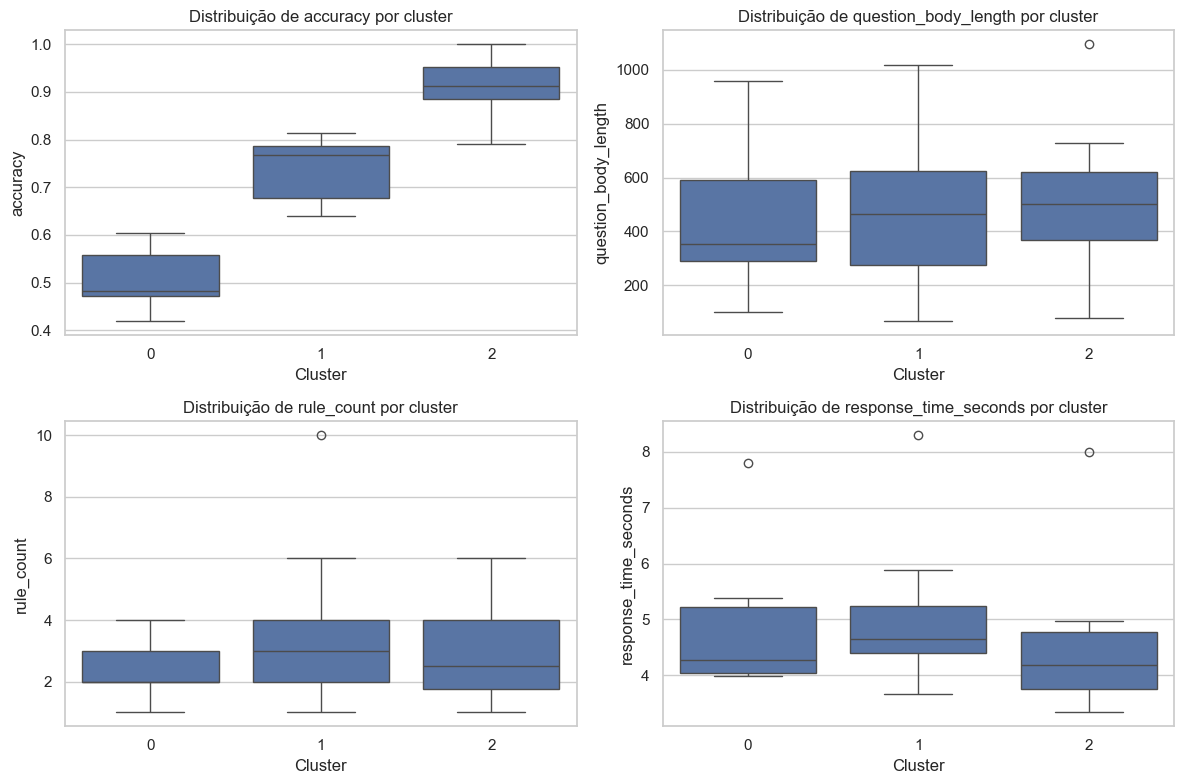

In [263]:
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# 1. Definir as colunas a analisar
# -----------------------
cols_to_plot = ["accuracy", "question_body_length", "rule_count", "response_time_seconds"]

# -----------------------
# 2. Criar os boxplots
# -----------------------
plt.figure(figsize=(12, 8))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=question_summary_df, x="cluster", y=col)
    plt.title(f"Distribuição de {col} por cluster")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.tight_layout()

plt.show()


In [264]:
# 1. Calcular acurácia média por combinação model_name + firac
accuracy_order = (
    question_long_df
    .groupby(["model_name", "firac"])["is_correct"]
    .mean()
    .sort_values(ascending=True)
)

# 2. Pivotar para o formato wide
question_wide_df = (
    question_long_df
    .pivot_table(
        index="question_id",
        columns=["model_name", "firac"],
        values="is_correct"
    )
)

# 3. Reordenar as colunas conforme a acurácia calculada
question_wide_df = question_wide_df[accuracy_order.index]

# 4. Flatten do MultiIndex nas colunas
question_wide_df.columns = [
    f"{model}_{firac}" for model, firac in question_wide_df.columns
]

# 5. Resetar o índice (opcional)
question_wide_df = question_wide_df.reset_index()

#question_wide_df = question_wide_df.dropna(axis=1, how="any")

question_wide_df.head()


,question_id,gemma-3-1b-it_FI___,gemma-3-1b-it_F____,gemma-3-1b-it_FIRA_,gemma-3-1b-it___L__,gemma-3-1b-it___R__,gemma-3-1b-it_____,gemma-3-1b-it_FIL__,gemma-3-4b-it_F____,gemma-3-4b-it_____,gemma-3-4b-it___L__,gemma-3-4b-it_FI___,gemma-3-4b-it_FIL__,gemma-3-1b-it_FIR__,gemma-3-1b-it_FIRAC,gemma-3-27b-it___L__,gemma-3-27b-it_____,gemini-2.5-flash-lite_____,gemma-3-27b-it_F____,gemma-3-4b-it___R__,gemma-3-12b-it_F____,gemma-3-12b-it_____,gemma-3-12b-it_FIL__,gemini-2.0-flash_F____,gemini-2.5-flash-lite_F____,gemini-2.5-flash-lite-preview-06-17_FI___,gemini-2.0-flash___L__,gemini-2.5-flash-lite___L__,gemma-3-12b-it_FI___,gemma-3-12b-it___L__,gemma-3-27b-it_FIL__,gemini-2.0-flash_____,gemma-3-4b-it_FIR__,gemini-2.5-flash-lite-preview-06-17___L__,gemini-2.5-flash-lite_FIL__,gemma-3-27b-it_FI___,gemini-2.0-flash-lite_FI___,gemini-2.0-flash-lite_F____,gemini-2.0-flash-lite___L__,gemini-2.0-flash-lite_____,gemini-2.5-flash-lite-preview-06-17_____,gemini-2.5-flash-lite-preview-06-17_F____,gemini-2.0-flash_FI___,gemini-2.5-flash-lite-preview-06-17_FIL__,gemini-2.0-flash-lite_FIL__,gemini-2.0-flash_FIL__,gemma-3-12b-it___R__,gemini-2.5-flash-lite_FI___,gemma-3-27b-it___R__,gemini-2.5-flash_FIL__,gemini-2.5-flash___L__,gemma-3-27b-it_FIR__,gemma-3-4b-it_FIRA_,gemini-2.5-flash_FI___,gemma-3-12b-it_FIR__,gemini-2.5-flash_F____,gemini-2.0-flash-lite___R__,gemini-2.5-flash_____,gemini-2.5-flash-lite-preview-06-17_FIR__,gemini-2.5-flash-lite___R__,gemini-2.5-flash-lite_FIR__,gemma-3-4b-it_FIRAC,gemini-2.5-pro_FIL__,gemini-2.5-flash-lite-preview-06-17___R__,gemini-2.0-flash-lite_FIR__,gemini-2.5-flash___R__,gemini-2.5-flash-lite-preview-06-17_FIRA_,gemini-2.5-flash_FIR__,gemini-2.5-pro_____,gemma-3-27b-it_FIRA_,gemini-2.5-pro___L__,gemini-2.0-flash___R__,gemini-2.0-flash_FIRAC,gemini-2.0-flash_FIRA_,gemini-2.0-flash_FIR__,gemini-2.5-flash-lite-preview-06-17_FIRAC,gemini-2.5-pro_FIRAC,gemini-2.5-pro_FIRA_,gemini-2.5-pro_FIR__,gemini-2.5-pro_FI___,gemini-2.5-flash-lite_FIRA_,gemini-2.5-flash-lite_FIRAC,gemini-2.5-pro_F____,gemma-3-27b-it_FIRAC,gemini-2.5-pro___R__,gemini-2.5-flash_FIRAC,gemini-2.5-flash_FIRA_,gemma-3-12b-it_FIRAC,gemma-3-12b-it_FIRA_,gemini-2.0-flash-lite_FIRAC,gemini-2.0-flash-lite_FIRA_
0,oab-10.pdf-094,0.0,0.0,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,oab-110.pdf-118,0.0,0.0,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,oab-112.pdf-140,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,oab-115.pdf-168,0.0,1.0,NaN,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,NaN,1.0,1.0,0.0,1.0,NaN,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,oab-13.pdf-123,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.

In [265]:
pd.set_option('display.max_rows', None)


# Conta o número de valores NaN por coluna
na_counts = question_wide_df.isna().sum()

# Mostra o resultado ordenado do maior para o menor
na_counts.sort_values(ascending=False)

gemma-3-1b-it_FIRA_                          43
gemma-3-1b-it_FIRAC                          42
gemma-3-1b-it_FIR__                          38
gemini-2.5-flash_____                         8
gemini-2.5-flash_F____                        8
gemini-2.5-flash_FIL__                        5
gemini-2.0-flash-lite_____                    4
gemini-2.5-flash___L__                        2
gemini-2.5-flash___R__                        1
gemini-2.5-flash-lite_FI___                   1
gemma-3-12b-it_FIR__                          0
gemini-2.0-flash-lite___R__                   0
gemini-2.5-pro_____                           0
gemini-2.5-flash_FI___                        0
gemma-3-4b-it_FIRA_                           0
gemini-2.5-flash-lite-preview-06-17_FIR__     0
gemini-2.5-flash-lite___R__                   0
gemini-2.5-flash-lite_FIR__                   0
gemma-3-4b-it_FIRAC                           0
gemini-2.5-pro_FIL__                          0
gemini-2.5-flash-lite-preview-06-17___R_

In [266]:
# Mantém apenas as colunas que começam com 'gemini'
question_wide_df = question_wide_df.filter(regex=r'^gemini')

# Verifica o resultado
question_wide_df.head()
question_wide_df = question_wide_df.dropna()

question_wide_df.head()

,gemini-2.5-flash-lite_____,gemini-2.0-flash_F____,gemini-2.5-flash-lite_F____,gemini-2.5-flash-lite-preview-06-17_FI___,gemini-2.0-flash___L__,gemini-2.5-flash-lite___L__,gemini-2.0-flash_____,gemini-2.5-flash-lite-preview-06-17___L__,gemini-2.5-flash-lite_FIL__,gemini-2.0-flash-lite_FI___,gemini-2.0-flash-lite_F____,gemini-2.0-flash-lite___L__,gemini-2.0-flash-lite_____,gemini-2.5-flash-lite-preview-06-17_____,gemini-2.5-flash-lite-preview-06-17_F____,gemini-2.0-flash_FI___,gemini-2.5-flash-lite-preview-06-17_FIL__,gemini-2.0-flash-lite_FIL__,gemini-2.0-flash_FIL__,gemini-2.5-flash-lite_FI___,gemini-2.5-flash_FIL__,gemini-2.5-flash___L__,gemini-2.5-flash_FI___,gemini-2.5-flash_F____,gemini-2.0-flash-lite___R__,gemini-2.5-flash_____,gemini-2.5-flash-lite-preview-06-17_FIR__,gemini-2.5-flash-lite___R__,gemini-2.5-flash-lite_FIR__,gemini-2.5-pro_FIL__,gemini-2.5-flash-lite-preview-06-17___R__,gemini-2.0-flash-lite_FIR__,gemini-2.5-flash___R__,gemini-2.5-flash-lite-preview-06-17_FIRA_,gemini-2.5-flash_FIR__,gemini-2.5-pro_____,gemini-2.5-pro___L__,gemini-2.0-flash___R__,gemini-2.0-flash_FIRAC,gemini-2.0-flash_FIRA_,gemini-2.0-flash_FIR__,gemini-2.5-flash-lite-preview-06-17_FIRAC,gemini-2.5-pro_FIRAC,gemini-2.5-pro_FIRA_,gemini-2.5-pro_FIR__,gemini-2.5-pro_FI___,gemini-2.5-flash-lite_FIRA_,gemini-2.5-flash-lite_FIRAC,gemini-2.5-pro_F____,gemini-2.5-pro___R__,gemini-2.5-flash_FIRAC,gemini-2.5-flash_FIRA_,gemini-2.0-flash-lite_FIRAC,gemini-2.0-flash-lite_FIRA_
1,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
5,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
6,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
10,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [267]:
from sklearn.cluster import KMeans
import pandas as pd

pd.set_option('display.max_columns', None)


# 1. Separar apenas as colunas numéricas
X = question_wide_df.select_dtypes(include="number")

# 2. Definir o número de clusters
n_clusters = 2

# 3. Rodar o K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
question_wide_df["cluster"] = kmeans.fit_predict(X)

# 4. Criar um DataFrame dos centróides
cluster_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns,
    index=[f"Cluster {i}" for i in range(n_clusters)]
)

# 5. Adicionar uma coluna com o tamanho de cada cluster
cluster_sizes = question_wide_df["cluster"].value_counts().sort_index()
cluster_df["size"] = cluster_sizes.values

# 6. Mostrar o resultado arredondado para melhor visualização
cluster_df = cluster_df.round(3)
cluster_df.head()


,gemini-2.5-flash-lite_____,gemini-2.0-flash_F____,gemini-2.5-flash-lite_F____,gemini-2.5-flash-lite-preview-06-17_FI___,gemini-2.0-flash___L__,gemini-2.5-flash-lite___L__,gemini-2.0-flash_____,gemini-2.5-flash-lite-preview-06-17___L__,gemini-2.5-flash-lite_FIL__,gemini-2.0-flash-lite_FI___,gemini-2.0-flash-lite_F____,gemini-2.0-flash-lite___L__,gemini-2.0-flash-lite_____,gemini-2.5-flash-lite-preview-06-17_____,gemini-2.5-flash-lite-preview-06-17_F____,gemini-2.0-flash_FI___,gemini-2.5-flash-lite-preview-06-17_FIL__,gemini-2.0-flash-lite_FIL__,gemini-2.0-flash_FIL__,gemini-2.5-flash-lite_FI___,gemini-2.5-flash_FIL__,gemini-2.5-flash___L__,gemini-2.5-flash_FI___,gemini-2.5-flash_F____,gemini-2.0-flash-lite___R__,gemini-2.5-flash_____,gemini-2.5-flash-lite-preview-06-17_FIR__,gemini-2.5-flash-lite___R__,gemini-2.5-flash-lite_FIR__,gemini-2.5-pro_FIL__,gemini-2.5-flash-lite-preview-06-17___R__,gemini-2.0-flash-lite_FIR__,gemini-2.5-flash___R__,gemini-2.5-flash-lite-preview-06-17_FIRA_,gemini-2.5-flash_FIR__,gemini-2.5-pro_____,gemini-2.5-pro___L__,gemini-2.0-flash___R__,gemini-2.0-flash_FIRAC,gemini-2.0-flash_FIRA_,gemini-2.0-flash_FIR__,gemini-2.5-flash-lite-preview-06-17_FIRAC,gemini-2.5-pro_FIRAC,gemini-2.5-pro_FIRA_,gemini-2.5-pro_FIR__,gemini-2.5-pro_FI___,gemini-2.5-flash-lite_FIRA_,gemini-2.5-flash-lite_FIRAC,gemini-2.5-pro_F____,gemini-2.5-pro___R__,gemini-2.5-flash_FIRAC,gemini-2.5-flash_FIRA_,gemini-2.0-flash-lite_FIRAC,gemini-2.0-flash-lite_FIRA_,size
Cluster 0,0.667,0.762,0.762,0.905,0.762,0.857,0.762,0.857,0.81,0.905,0.857,0.81,0.905,0.952,0.857,0.952,0.905,1.0,0.952,0.952,0.952,0.857,0.905,0.857,0.952,0.952,1.00,1.00,1.0,1.0,0.952,1.00,1.00,0.952,1.0,1.0,1.0,1.00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,21
Cluster 1,0.250,0.000,0.000,0.000,0.250,0.250,0.250,0.000,0.25,0.000,0.250,0.25,0.250,0.000,0.250,0.000,0.250,0.0,0.000,0.250,0.750,1.000,1.000,1.000,0.750,0.750,0.75,0.75,1.0,1.0,1.000,0.75,0.75,1.000,1.0,1.0,1.0,0.75,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4


In [270]:
import pandas as pd
import numpy as np

# 1. Criar matriz: linhas = provas (ou observações), colunas = question_id, valores = is_correct
#    Se quisermos alpha para todo o exame, podemos agregar por prova ou usar todas as respostas juntas.
exam_matrix = question_long_df.pivot_table(
    index='pdf_filename',       # ou outro identificador de observação
    columns='question_id',
    values='is_correct'
)

# 2. Função para calcular alpha de Cronbach
def cronbach_alpha(df):
    df = df.dropna(axis=1, how='all')  # remover colunas sem dados
    k = df.shape[1]                     # número de itens
    item_var = df.var(axis=0, ddof=1)   # variância de cada item
    total_var = df.sum(axis=1).var(ddof=1)  # variância total da soma
    alpha = (k / (k-1)) * (1 - item_var.sum() / total_var)
    return alpha

# 3. Calcular alpha
alpha_exam = cronbach_alpha(exam_matrix)
print("Alpha de Cronbach do exame:", alpha_exam)


Alpha de Cronbach do exame: 1.0222222222222221
